In [ ]:
!pip install tavily-python langchain groq==0.29.0 crewai==0.121.1 crewai_tools==0.45.0 litellm==1.68.0 pypdf langchain-community langchain_chroma faiss-cpu langchain-tavily sentence-transformers

  Using cached crewai-0.121.1-py3-none-any.whl.metadata (35 kB)
  Using cached crewai_tools-0.45.0-py3-none-any.whl.metadata (10 kB)
  Using cached auth0_python-5.7.0-py3-none-any.whl.metadata (12 kB)
INFO: pip is looking at multiple versions of embedchain to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of embedchain to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
  Using cached langchain_chroma-1.1.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached langchain_chroma-1.0.0-py3-none-any.whl.metadata (1.9 kB)
INFO: pip is looking at multiple versions of langchain-tavily to determine which version is compatible with oth

In [ ]:
import groq

import importlib.metadata

print("CrewAI:", importlib.metadata.version("crewai"))
print("LiteLLM:", importlib.metadata.version("litellm"))
print("Groq:", importlib.metadata.version("groq"))

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

from tavily import TavilyClient # real-time web search
from langchain.agents import create_agent
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader # load folder of pdfs
from langchain_chroma import Chroma # to see what documents match a query.
from langchain_text_splitters import RecursiveCharacterTextSplitter # used to create chunks which will be converted into an embedding vector
from langchain_community.embeddings import HuggingFaceEmbeddings
import faiss
from langchain_community.vectorstores import FAISS # Import FAISS class

import crewai_tools
from crewai.tools import BaseTool
from crewai_tools import PDFSearchTool, TavilySearchTool
from crewai import Agent, Task, Crew, LLM
import groq

from pydantic import Field

from dotenv import load_dotenv
import asyncio
import litellm

import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


In [ ]:
#API Keys for Groq, HuggingFace and Tavily
os.environ["HF_TOKEN"] = 'hf_'
os.environ['GROQ_API_KEY'] = 'gsk_'
os.environ["TAVILY_API_KEY"] = 'tvly-'

# Data Loading and Preprocessing

In [5]:
path = "/content/drive/MyDrive/Intelligence Tech Solutions /crew_data"

In [6]:
def loader(pathway, chunk_size, chunk_overlap, model, query, db_type="faiss"):
    # Load PDFs
    load = DirectoryLoader(
        pathway,
        glob="**/*.pdf",
        loader_cls=PyPDFLoader
    )

    documents = load.load()
    print(f"Pages loaded: {len(documents)}")

    # Split documents
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap
    )

    chunks = splitter.split_documents(documents)

    # Embeddings
    embedding_model = HuggingFaceEmbeddings(
        model_name=model
    )

    # Choose vector store
    if db_type.lower() == "faiss":
        vectorstore = FAISS.from_documents(
            chunks,
            embedding_model
        )

        vectorstore.save_local("faiss_index")

    elif db_type.lower() == "chroma":
        vectorstore = Chroma.from_documents(
            documents=chunks,
            embedding=embedding_model,
            persist_directory="./chroma_db"
        )

    else:
        raise ValueError("db_type must be 'faiss' or 'chroma'")

    # Retriever
    retriever = vectorstore.as_retriever()

    # Search
    results = vectorstore.similarity_search(query, k=3)

    print("\nTop Results:")
    for i, doc in enumerate(results, 1):
        print(f"\nResult {i}")
        print(doc.page_content[:500])

    return vectorstore, retriever

# Using FAISS and HuggingFace Model

In [7]:
loader(path,
    model="sentence-transformers/all-MiniLM-L6-v2",
    chunk_size=1000,
    chunk_overlap=200,
    query="What are Electronic Health Records?",
    db_type="faiss"
)

Pages loaded: 101


/tmp/ipykernel_11115/2618243174.py:21: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Top Results:

Result 1
A PREPRINT - JULY 25, 2024
[10] Inadequate hand-off communication. Sentinel Event Alert. 2017 Sep 12;(58):1-6. PMID: 28914519.
[11] Malpractice risks in communication failures: 2015 Annual benchmarking report. [Internet]. [cited 2024 Jun 23].
Available from: https://psnet.ahrq.gov/issue/malpractice-risks-communication-failures-2015-annual-benchmarking-
report.
[12] Geiger G, Merrilees K, Walo R, Gordon D, Kunov H. An analysis of the paper-based health record: information
content and its implicat

Result 2
summarization tasks, and its transformative impact on the clinician’s potential, including but not
limited to reductions of administrative burden and improved patient-centered care.
1 Introduction
Patient information is critical in the delivery of effective care – thousands of practices, tools, and techniques have been
developed in patient interview, health record storage, and physical examination purely for the sake of effective usage of
key patient informatio

(<langchain_community.vectorstores.faiss.FAISS at 0x793622f9f350>,
 VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x793622f9f350>, search_kwargs={}))

# Using Chroma and HuggingFace

In [8]:
vectorstore, retriever = loader(path,
    model="sentence-transformers/all-MiniLM-L6-v2",
    chunk_size=2000,
    chunk_overlap=150,
    query="What are Electronic Health Records?",
    db_type="chroma"
    )

Pages loaded: 101


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Top Results:

Result 1
A PREPRINT - JULY 25, 2024
[10] Inadequate hand-off communication. Sentinel Event Alert. 2017 Sep 12;(58):1-6. PMID: 28914519.
[11] Malpractice risks in communication failures: 2015 Annual benchmarking report. [Internet]. [cited 2024 Jun 23].
Available from: https://psnet.ahrq.gov/issue/malpractice-risks-communication-failures-2015-annual-benchmarking-
report.
[12] Geiger G, Merrilees K, Walo R, Gordon D, Kunov H. An analysis of the paper-based health record: information
content and its implicat

Result 2
H.Murtaza,M.Ahmed,N.F.Khanetal. ComputerScienceReview48(2023)100546
[7] F.Li,X.Zou,P.Liu,J.Y.Chen,Newthreatstohealthdataprivacy,BMC
Bioinformatics 12 (12) (2011) S7, http://dx.doi.org/10.1186/1471-2105-
12-S12-S7.
[8] C. for, O. Rights (OCR), HIPAA for Professionals, HHS.gov, 2015, https://
www.hhs.gov/hipaa/for-professionals/index.html(accessedOct.25,2020).
[9] General data protection regulation (GDPR) – official legal text, general
data protection regulation 

PCA & t-SNE from FAISS



In [9]:
def visualize_embeddings(
    embeddings,
    texts=None,
    method="pca",
    annotate=False,
    figsize=(8, 6)
):
    embeddings = np.array(embeddings)

    if method.lower() == "pca":
        reducer = PCA(n_components=2)

    elif method.lower() == "tsne":
        reducer = TSNE(
            n_components=2,
            perplexity=min(10, len(embeddings)-1),
            random_state=42
        )

    else:
        raise ValueError("method must be 'pca' or 'tsne'")

    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=figsize)
    plt.scatter(reduced[:, 0], reduced[:, 1])

    if annotate:
        n = min(50, len(reduced))

        for i in range(n):
            label = str(i)

            if texts is not None:
                label = texts[i][:20]

            plt.annotate(
                label,
                (reduced[i, 0], reduced[i, 1]),
                fontsize=6
            )

    plt.title(f"{method.upper()} Visualization")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

    return reduced

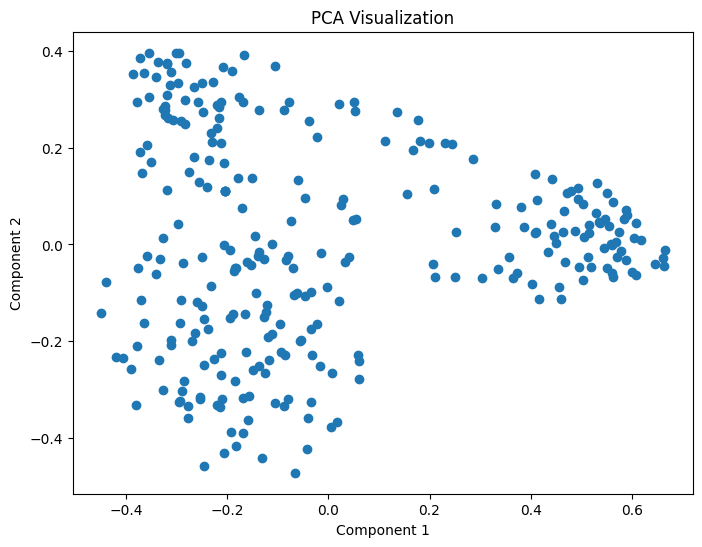

array([[ 5.99449817e-01, -5.62441288e-02],
       [ 4.72646927e-01,  1.06399723e-01],
       [ 5.04191446e-01,  8.35688278e-02],
       [-2.04681878e-01,  1.10992894e-01],
       [-2.04681878e-01,  1.10992894e-01],
       [-2.04681878e-01,  1.10992894e-01],
       [-2.04681878e-01,  1.10992894e-01],
       [ 5.51511805e-01,  1.06278908e-01],
       [ 5.35121676e-01,  4.60752154e-02],
       [ 4.50604198e-01,  3.78109861e-03],
       [ 4.07729463e-01,  2.41976347e-02],
       [ 4.34487899e-01, -1.55003806e-02],
       [ 5.06111587e-01,  1.44814876e-02],
       [ 3.36390893e-01, -5.02121394e-02],
       [ 3.86702255e-01,  3.67779879e-02],
       [ 5.36626681e-01,  4.50211362e-02],
       [ 4.94746443e-01, -4.66149428e-02],
       [ 5.15083051e-01,  2.28243161e-02],
       [ 4.88267455e-01,  2.86201161e-02],
       [ 5.87948313e-01, -3.19484420e-02],
       [ 4.10726422e-01,  2.58103699e-02],
       [ 5.59619310e-01,  1.04193968e-04],
       [ 5.70578945e-01, -2.58310375e-02],
       [ 5.

In [10]:
data = vectorstore._collection.get(
    include=["embeddings", "documents"]
)

embeddings = data["embeddings"]

visualize_embeddings(
    embeddings,
    method="pca"
)

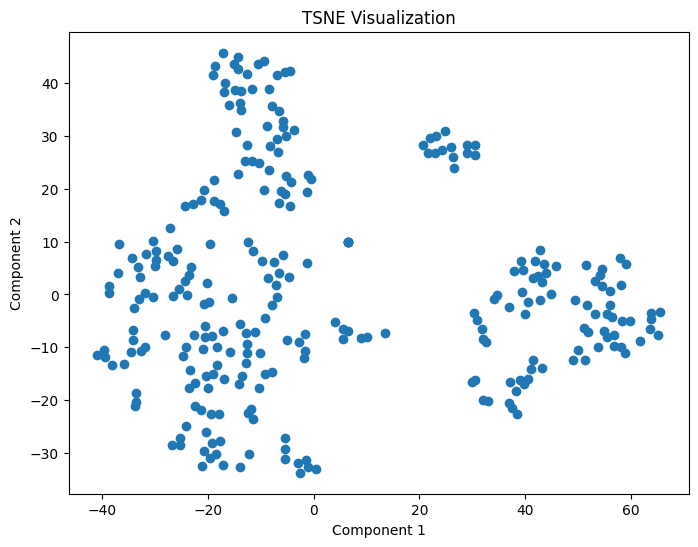

array([[ 3.7851395e+01,  4.4889812e+00],
       [ 4.1905304e+01,  6.4175167e+00],
       [ 4.4864853e+01,  5.9473667e-02],
       [ 6.3783727e+00,  9.9003582e+00],
       [ 6.3783727e+00,  9.9003582e+00],
       [ 6.3783727e+00,  9.9003582e+00],
       [ 6.3783727e+00,  9.9003582e+00],
       [ 4.3993126e+01,  4.0268178e+00],
       [ 4.3129921e+01,  2.3361413e+00],
       [ 3.9657001e+01,  4.7133918e+00],
       [ 3.1792315e+01, -6.4706454e+00],
       [ 3.4068596e+01, -8.3274573e-01],
       [ 4.0464771e+01, -1.3449235e+00],
       [ 4.1087173e+01, -1.4013728e+01],
       [ 3.0856834e+01, -4.8551397e+00],
       [ 3.9428207e+01,  5.2383554e-01],
       [ 3.9241718e+01,  6.4253941e+00],
       [ 4.2820255e+01, -1.0716807e+00],
       [ 4.9419838e+01, -9.5237833e-01],
       [ 5.1612034e+01,  5.5508394e+00],
       [ 4.2732750e+01,  8.3700705e+00],
       [ 4.1442001e+01,  3.0886266e+00],
       [ 4.3607365e+01,  5.6923828e+00],
       [ 3.4687073e+01, -1.6277434e-01],
       [ 4.15773

In [11]:
visualize_embeddings(
    embeddings,
    method="tsne"
)

# AI Agent using HuggingFace

In [12]:
async def huggingface_agent():
  search_tool = TavilySearchTool()


  llm = LLM(
      model="openai/meta-llama/Llama-3.1-70B-Instruct",
      api_key=os.environ["HF_TOKEN"],
      base_url="https://router.huggingface.co/v1"
  )

  trend_analyst = Agent(
      role="Trend Analyst",
      goal="Identify and summarize the latest AI trends",
      backstory="""
      You are an expert technology analyst who tracks
      developments in AI, machine learning and LLMs.
      """,
      tools=[search_tool],
      llm=llm,
  )

  trend_task = Task(
      description="""
      Research the latest AI news and summarize
      the five most important developments.
      """,
      expected_output="""
      A report listing the five most important AI developments,
      with a brief explanation of each and why it matters.
      """,
      agent=trend_analyst
  )

  crew = Crew(
      agents=[trend_analyst],
      tasks=[trend_task],
  )

  result = await crew.kickoff_async()
  print(result)
  report = result.raw if hasattr(result, "raw") else str(result)

  with open("hf_report.md", "w", encoding="utf-8") as f:
    f.write(report)

await huggingface_agent()


The five most important AI developments in 2026 are:

1. Agentic AI: The use of AI agents that can perform tasks autonomously, making decisions and taking actions without human intervention.
2. Domain-Specific Models: The development of AI models that are tailored to specific industries or domains, providing more accurate and relevant results.
3. Context Engineering: The process of designing and building AI systems that can understand and adapt to different contexts, such as language, culture, and environment.
4. AI Governance Platforms: The use of platforms that enable organizations to manage and govern their AI systems, ensuring transparency, accountability, and compliance.
5. Responsible AI: The development of AI systems that are fair, transparent, and accountable, and that prioritize human well-being and safety.

These trends are expected to shape the future of AI and have significant impacts on businesses, societies, and individuals.
